In [1]:
import pandas as pd
import deeplay
import importlib
import data.MultiAssetDataset_v3
importlib.reload(data.MultiAssetDataset_v3)
from data.MultiAssetDataset_v3 import MultiAssetSequencedDataset
from torch.utils.data import DataLoader
import torch
import numpy as np
np.random.seed(42)
torch.manual_seed(42)

df = pd.read_csv("data/OMXS22_model_features_raw.csv", index_col = "Date", parse_dates = True)

tickers = df["Ticker"].unique().tolist()
print(df.head())
features = ["Close"]
target_col = "Close"
window   = 100
window_step_length = 6
#horizon  = [i for i in range(1, 11)]
horizon = [10]


train_stop = pd.Timestamp("2016-01-01")
val_stop = pd.Timestamp("2022-11-23")

df_train = df[df.index < train_stop].copy()

df_val   = df[(df.index >= train_stop) & (df.index < val_stop)].copy()
df_test  = df[df.index >= val_stop].copy()
df_val_test = df[df.index >= train_stop].copy()


ds_train = MultiAssetSequencedDataset(df_train, tickers, features, target_col, False, window, window_step_length=50, horizon=horizon, num_permutations=75)
ds_train.create()
ds_val   = MultiAssetSequencedDataset(df_val,   tickers, features, target_col, False, window, window_step_length=max(horizon), horizon=horizon)
ds_val.create()
ds_test  = MultiAssetSequencedDataset(df_test,  tickers, features, target_col, False, window, window_step_length=max(horizon), horizon=horizon)
ds_test.create()
ds_val_test = MultiAssetSequencedDataset(df_val_test,  tickers, features, target_col, False, window, window_step_length=max(horizon), horizon=horizon)
ds_val_test.create()


train_loader = DataLoader(ds_train, batch_size=32, shuffle=True)
val_loader   = DataLoader(ds_val,   batch_size=32)
test_loader  = DataLoader(ds_test,  batch_size=32)

print(f"Train set length: {len(ds_train)}")
print(f"Train set input shape: {ds_train[0][0].shape}")
print(f"Train set target shape: {ds_train[0][1].shape}")
print(f"Val set length: {len(ds_val)}")
print(f"Dataset length: {len(ds_train) + len(ds_val) + len(ds_test)}")

print(f"Test set number of days: {len(df_test.index.unique())}")
print(f"Test set number of sequences: {len(ds_test)}")

print(f"first day of test set trading: {ds_test.target_dates[0]}")

               Ticker       Close    Return  LogReturn      Volume  SMA20  \
Date                                                                        
2000-01-04  ASSA-B.ST   23.572845 -0.050000  -0.051293   1681974.0    0.0   
2000-01-04  ATCO-A.ST    3.945862 -0.044747  -0.045779  29996128.0    0.0   
2000-01-04  ATCO-B.ST    3.067595 -0.047809  -0.048989   3956152.0    0.0   
2000-01-04     AZN.ST  279.147308 -0.031655  -0.032166   2738295.0    0.0   
2000-01-04  ELUX-B.ST   31.041374 -0.013889  -0.013986   3385217.0    0.0   

                 EMA20      RSI14  ReturnVola20  OMXS30_ret  USD_SEK_ret  \
Date                                                                       
2000-01-04   26.375874  74.255529      0.027978   -0.034201    -0.007497   
2000-01-04    3.990954  48.970023      0.024745   -0.034201    -0.007497   
2000-01-04    3.121727  52.314221      0.029787   -0.034201    -0.007497   
2000-01-04  278.932230  30.501235      0.017450   -0.034201    -0.007497   
2000

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from multi_asset_models.MultiAssetLSTM import MultiAssetLSTM
from train.Trainer import Trainer

model = MultiAssetLSTM(
    n_assets=len(tickers),
    n_features=len(features),
    hidden_size=132,
    num_layers=2,
    dropout=0.2,
    horizon=horizon
)

criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs   = 25
patience     = num_epochs
save_path    = "best_multiasset_lstm.pt"

trainer = Trainer(model, optimizer, criterion)
history = trainer.fit(
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = num_epochs,
    patience     = patience,
    save_path    = save_path
)

model.load_state_dict(torch.load(save_path))

Epoch 1/25 - train_loss: 0.8624, val_loss: 0.9293
Epoch 2/25 - train_loss: 0.7860, val_loss: 0.9276
Epoch 3/25 - train_loss: 0.7724, val_loss: 0.9126
Epoch 4/25 - train_loss: 0.7658, val_loss: 0.9306
Epoch 5/25 - train_loss: 0.7551, val_loss: 0.9229
Epoch 6/25 - train_loss: 0.7470, val_loss: 0.9340
Epoch 7/25 - train_loss: 0.7356, val_loss: 0.9035
Epoch 8/25 - train_loss: 0.7260, val_loss: 0.9387
Epoch 9/25 - train_loss: 0.7123, val_loss: 0.9544
Epoch 10/25 - train_loss: 0.7017, val_loss: 0.9721
Epoch 11/25 - train_loss: 0.6930, val_loss: 0.9739
Epoch 12/25 - train_loss: 0.6837, val_loss: 0.9581
Epoch 13/25 - train_loss: 0.6725, val_loss: 0.9532
Epoch 14/25 - train_loss: 0.6652, val_loss: 0.9506
Epoch 15/25 - train_loss: 0.6609, val_loss: 0.9427
Epoch 16/25 - train_loss: 0.6510, val_loss: 0.9477
Epoch 17/25 - train_loss: 0.6426, val_loss: 0.9893
Epoch 18/25 - train_loss: 0.6409, val_loss: 0.9711
Epoch 19/25 - train_loss: 0.6341, val_loss: 0.9631
Epoch 20/25 - train_loss: 0.6269, val_lo

<All keys matched successfully>

Naive MAE: 2.0158


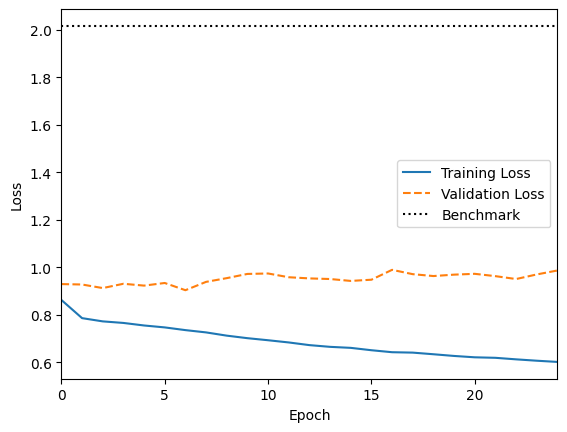

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training(epochs, train_losses, val_losses, benchmark):
    """Plot the training and validation losses."""
    plt.plot(range(epochs), train_losses, label="Training Loss")
    plt.plot(range(epochs), val_losses, "--", label="Validation Loss")
    plt.plot([0, epochs - 1], [benchmark, benchmark], ":k", label="Benchmark")
    plt.xlabel("Epoch")
    plt.xlim([0, epochs - 1])
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

ys = []
for _, y in DataLoader(ds_test, batch_size=128):
    ys.append(y)
ys = torch.cat(ys, dim=0).numpy()
if ys.ndim == 3:
    ys = ys[:, :, 0]

naive_errors = np.abs(ys[max(horizon):] - ys[:-max(horizon)])
naive_mae = naive_errors.mean()

print(f"Naive MAE: {naive_mae:.4f}")

train_losses = history['train_loss']
val_losses   = history['val_loss']
plot_training(25, train_losses, val_losses, benchmark = naive_mae)

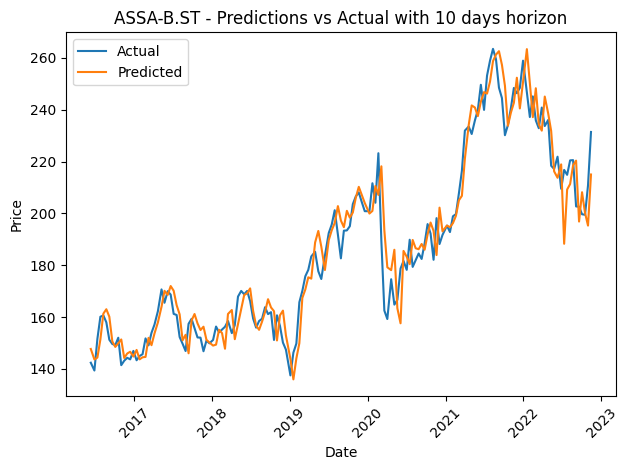

Accuracy: 0.0475
Total accuracy on last horizon: 0.0475
ASSA-B.ST: 0.0357
ATCO-A.ST: 0.0440
ATCO-B.ST: 0.0435
AZN.ST: 0.0415
ELUX-B.ST: 0.0539
ERIC-B.ST: 0.0557
GETI-B.ST: 0.0598
HEXA-B.ST: 0.0444
HM-B.ST: 0.0634
INVE-B.ST: 0.0317
KINV-B.ST: 0.0518
NDA-SE.ST: 0.0429
NIBE-B.ST: 0.0568
SAAB-B.ST: 0.0639
SAND.ST: 0.0482
SCA-B.ST: 0.0461
SEB-A.ST: 0.0407
SHB-A.ST: 0.0397
SKF-B.ST: 0.0523
SWED-A.ST: 0.0437
TEL2-B.ST: 0.0366
VOLV-B.ST: 0.0483
Stock accuracy: 0.0357


In [5]:
import importlib
import functions.plot_predictions
importlib.reload(functions.plot_predictions)
from functions.plot_predictions import plot_predictions

model.load_state_dict(torch.load("best_multiasset_lstm.pt"))
model.eval()
idx = 0
plot_predictions(
    idx,
    tickers,
    val_loader.dataset,
    model,
    0,
    20000
)

# Test on val-set to adjust optimization

               Close
Date                
2000-01-03  1.000000
2000-01-04  0.980766
2000-01-05  0.980568
2000-01-06  0.980568
2000-01-07  0.950247
Scaled returns: [1.00025049 1.00463494 0.99214894 0.98047284 0.98713698 0.97577369
 0.98784574 0.98233698 0.96817283 0.94413882]
Weights: [7.9446848e-12 1.4039480e-11 9.0398782e-12 4.0844360e-01 3.9156325e-02
 1.0910359e-01 0.0000000e+00 0.0000000e+00 4.8089847e-02 7.4189214e-12
 7.8415746e-12 1.8036069e-12 2.1922289e-11 1.6460662e-01 5.8769513e-12
 4.2136624e-12 4.4272430e-02 0.0000000e+00 1.7352822e-01 2.3453006e-12
 1.2799370e-02 1.9256992e-12]
Full horizon predictions: tensor([147.7105,  33.3719,  29.3858, 475.3659, 138.9143,  51.6164, 107.7171,
         45.7558, 179.7949,  60.3934,  97.3328,  76.4508,  16.6938,  61.2588,
         67.6348,  44.3628,  54.9646,  72.7858, 114.1953, 101.5156,  42.1362,
         66.0404])
Last know prices: tensor([146.9625,  32.6382,  28.9454, 463.9162, 132.5318,  51.6390, 106.7377,
         44.5239, 178.1694

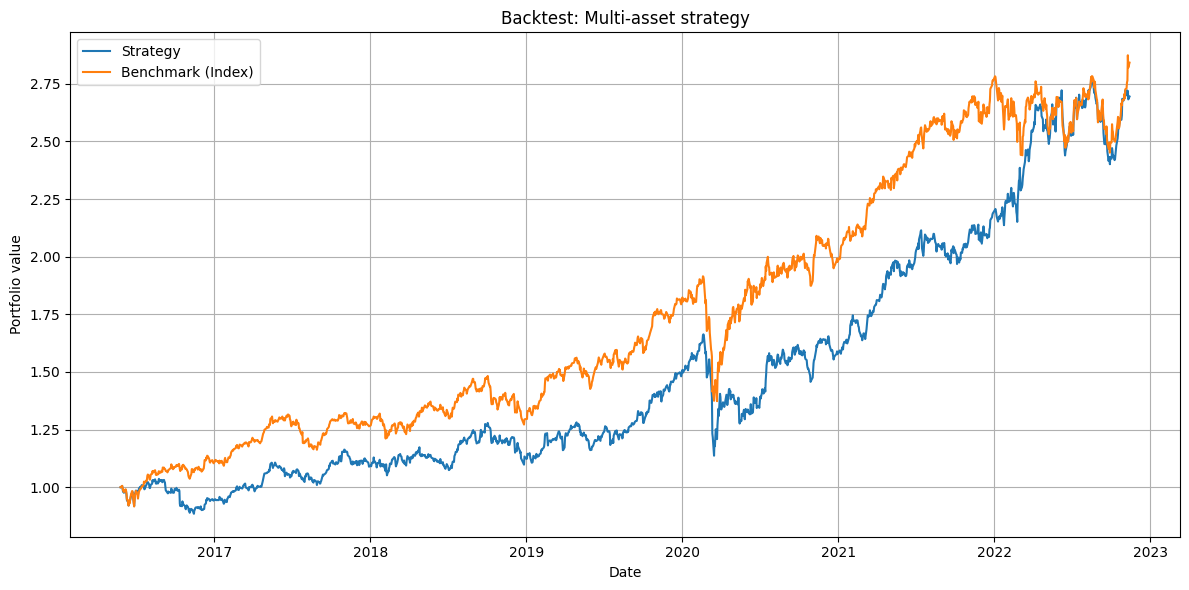

[[7.944684840555105e-12, 1.4039479648286779e-11, 9.039878220984399e-12, 0.4084435999393463, 0.03915632516145706, 0.10910359025001526, 0.0, 0.0, 0.04808984696865082, 7.418921380009103e-12, 7.84157461186652e-12, 1.8036068515428494e-12, 2.1922288637177267e-11, 0.16460661590099335, 5.876951269384589e-12, 4.2136624051059e-12, 0.04427243024110794, 0.0, 0.17352822422981262, 2.345300603029399e-12, 0.012799370102584362, 1.9256991834470938e-12], [0.0, 0.0, 0.0, 0.35501959919929504, 0.026304053142666817, 0.06707846373319626, 0.1012222021818161, 2.6457187135564553e-12, 0.07060477882623672, 0.0, 0.0, 0.0, 0.0, 0.1571618765592575, 0.0, 0.0, 0.05391236022114754, 0.0, 0.15682028234004974, 0.0, 0.011876370757818222, 0.0], [0.0, 4.44893210813091e-12, 4.098112474371085e-12, 0.49115243554115295, 0.07439412921667099, 0.1223173439502716, 0.0, 1.416126872884338e-12, 1.6423937947498968e-12, 7.877800842215343e-12, 1.1939074728850585e-11, 2.249487054961641e-12, 8.299087111973691e-12, 0.09896369278430939, 1.8349

In [8]:
import portfolio_optimizers.portfolio_optimizer 
importlib.reload(portfolio_optimizers.portfolio_optimizer)
from portfolio_optimizers.portfolio_optimizer import PortfolioWeightOptimizer
import importlib
import functions.backtest_multi_asset
importlib.reload(functions.backtest_multi_asset)

from functions.backtest_multi_asset import backtest_multi_asset
df_prices = df_val.copy()

df_index_raw = pd.read_csv("data/MCAP_22_Index_raw.csv", index_col="Date", parse_dates=True)
df_index = df_index_raw.copy()
df_index.columns = ["Close"]
print(df_index.head())

weight_optimizer = PortfolioWeightOptimizer(
    strategy="sharpe_opt",
    multi_horizon=True,
    risk_aversion=1.
)

result = backtest_multi_asset(
    ds_val,
    model,
    weight_optimizer,
    df_prices,
    index_df=df_index,
    plot=True,
    trading_cost=0.001,
)
print(result["weights"])
print(f"Mean weights: {np.array(result['weights']).mean(axis=0)}")

               Close
Date                
2000-01-03  1.000000
2000-01-04  0.980766
2000-01-05  0.980568
2000-01-06  0.980568
2000-01-07  0.950247
Scaled returns: [1.01082049 1.00863888 1.01041995 1.01653438 1.02017652 1.0191554
 0.99977922 1.04487599 1.04647468 1.03412541]
Weights: [2.36425683e-01 6.47532306e-11 3.23482275e-01 3.14823866e-01
 6.17570550e-10 3.48444676e-11 1.21892274e-10 7.14517508e-12
 6.78350820e-10 2.42846975e-11 3.11442094e-10 0.00000000e+00
 1.79399537e-10 1.56410113e-02 1.13474855e-10 0.00000000e+00
 0.00000000e+00 1.09627143e-01 2.98889885e-10 0.00000000e+00
 6.70774478e-11 0.00000000e+00]
Full horizon predictions: tensor([ 226.1076,  125.6012,  112.6775, 1529.4420,  144.1636,   59.5036,
         248.2037,  119.7335,  139.0934,  203.8682,  170.1337,  118.0683,
         119.8747,  159.8167,  212.3995,  129.2210,  106.2617,   85.5622,
         194.1811,  158.2843,   93.5003,  196.8899])
Last know prices: tensor([ 224.6278,  124.5393,  111.7046, 1514.2098,  135.100

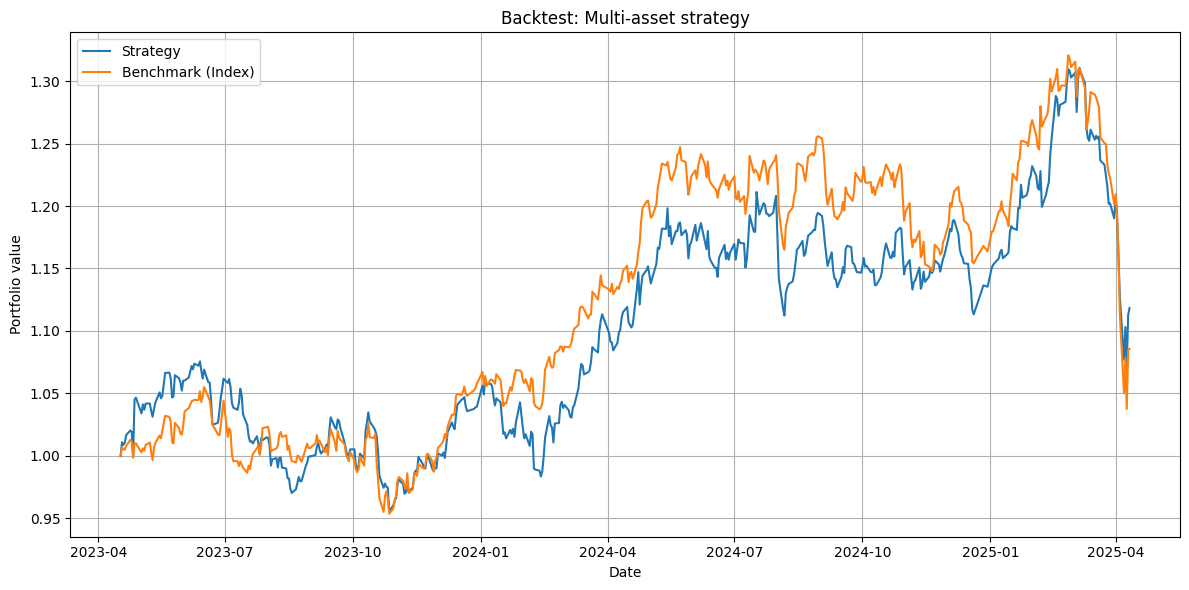

[[0.23642568290233612, 6.475323055532556e-11, 0.3234822750091553, 0.31482386589050293, 6.175705502542428e-10, 3.4844467589056904e-11, 1.2189227405201564e-10, 7.1451750766060584e-12, 6.783508199603716e-10, 2.428469751680762e-11, 3.114420943362006e-10, 0.0, 1.7939953689261046e-10, 0.01564101129770279, 1.1347485451285166e-10, 0.0, 0.0, 0.1096271425485611, 2.98889885064213e-10, 0.0, 6.70774477629088e-11, 0.0], [0.26230743527412415, 2.29888982850035e-10, 0.11055633425712585, 0.27593204379081726, 0.0, 0.21321576833724976, 7.742750884887073e-11, 8.58701304506937e-11, 0.0, 0.0, 0.0, 0.0, 0.0, 0.023661766201257706, 0.0, 3.211493571075863e-10, 0.0, 0.11432665586471558, 0.0, 0.0, 4.153692667596687e-10, 4.889652918671494e-11], [0.27364152669906616, 3.298536790929951e-11, 0.06614784896373749, 0.2668766379356384, 3.138163990820675e-12, 0.2534526288509369, 1.8971619414331897e-11, 4.88968067424711e-11, 2.1327042909469185e-10, 4.704502412633538e-11, 1.8819903968569918e-10, 9.462870764753717e-11, 8.3974

In [9]:
import portfolio_optimizers.portfolio_optimizer 
importlib.reload(portfolio_optimizers.portfolio_optimizer)
from portfolio_optimizers.portfolio_optimizer import PortfolioWeightOptimizer
import importlib
import functions.backtest_multi_asset
importlib.reload(functions.backtest_multi_asset)

from functions.backtest_multi_asset import backtest_multi_asset
df_prices = df_test.copy()

df_index_raw = pd.read_csv("data/MCAP_22_Index_raw.csv", index_col="Date", parse_dates=True)
df_index = df_index_raw.copy()
df_index.columns = ["Close"]
print(df_index.head())

weight_optimizer = PortfolioWeightOptimizer(
    strategy="sharpe_opt",
    multi_horizon=True,
    risk_aversion=1.
)

result_lstm = backtest_multi_asset(
    ds_test,
    model,
    weight_optimizer,
    df_prices,
    index_df=df_index,
    plot=True,
    trading_cost=0.001,
)
print(result_lstm["weights"])
print(f"Mean weights: {np.array(result_lstm['weights']).mean(axis=0)}")
print(f"dates: {0}")

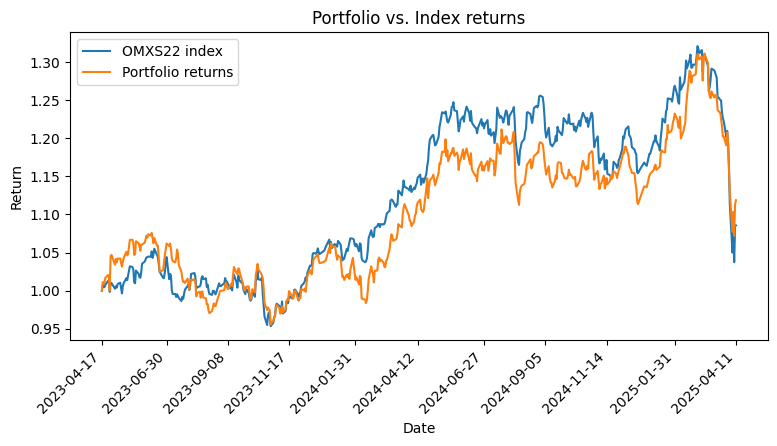

Last portfolio value: 1.1187
Last index value: 1.0856
Portfolio dates = 2023-04-17 00:00:00 to 2025-04-11 00:00:00


In [10]:
portfolio_dates = result_lstm["dates"]
portfolio_vals = result_lstm["values"]
index_vals = result_lstm["benchmark"]


plt.figure(figsize=(9, 4))
if index_vals is not None:
    plt.plot(portfolio_dates[:], np.array(index_vals[:])/index_vals[0], label="OMXS22 index")
plt.plot(portfolio_dates[:], np.array(portfolio_vals[:])/portfolio_vals[0], label="Portfolio returns")
plt.xlabel("Date")
plt.xticks(
        portfolio_dates[::50], 
        #[d.strftime('%Y-%m-%d') for d in dates],
        rotation=45, ha='right'
    )
plt.ylabel("Return")
plt.title("Portfolio vs. Index returns")
plt.legend()
plt.show()
print(f"Last portfolio value: {(np.array(portfolio_vals[:])/portfolio_vals[0])[-1]:.4f}")
print(f"Last index value: {(np.array(index_vals[:])/index_vals[0])[-1]:.4f}")
print(f"Portfolio dates = {portfolio_dates[0]} to {portfolio_dates[-1]}")

In [11]:
import torch.nn as nn

class CrossAttentionLSTMV1(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_hidden_layers, out_dim, dropout, num_heads):
        super().__init__()
        self.gru_model = nn.LSTM(in_dim, hidden_dim, num_layers=num_hidden_layers, dropout=dropout, batch_first=True)
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.cross_attn = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, kdim=hidden_dim, vdim=hidden_dim, dropout=0, batch_first=True)
        self.fuse_fc = nn.Sequential(
            nn.Linear(hidden_dim*2, hidden_dim),
            nn.ReLU()
        )
        self.fc = nn.Linear(hidden_dim, out_dim)
        self._stored_attn_weights = None

    def get_attn_weights(self):
        return self._stored_attn_weights

    def forward(self, x):
        gru_out, _ = self.gru_model(x)

        x_proj = self.input_proj(x)

        cross_attn_out, cross_attn_weights = self.cross_attn(query=gru_out, key=x_proj, value=x_proj)

        self._stored_attn_weights = cross_attn_weights.detach()
        #print('gru:', gru_out)
        #print('cross attn: ', cross_attn_out)

        combined = cross_attn_out+gru_out
        #fused = self.fuse_fc(combined)
        #print(combined.shape)

        final_step = combined[:, -1, :]
        #print(final_step.shape)

        output = self.fc(final_step)

        return output

In [12]:
import deeplay as dl
cross_attention_lstm_model = CrossAttentionLSTMV1(in_dim=len(tickers)*len(features), hidden_dim=144, num_hidden_layers=2, out_dim=len(tickers)*len(horizon), dropout=0.2, num_heads=24)

cross_attention_lstm_reg = dl.Regressor(cross_attention_lstm_model, optimizer=dl.Adam(lr=0.001)).create()

trainer_cross_lstm = dl.Trainer(max_epochs=25, accelerator="auto")
trainer_cross_lstm.fit(cross_attention_lstm_reg, train_loader, val_loader)

train_losses = trainer_cross_lstm.history.history["train_loss_epoch"]["value"]
val_losses = trainer_cross_lstm.history.history["val_loss_epoch"]["value"][1:]


  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | train
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 395 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
395 K     Trainable params
0         Non-trainable params
395 K     Total params
1.582     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

C:\Users\peogr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


C:\Users\peogr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 24: 100%|██████████| 188/188 [00:20<00:00,  8.99it/s, v_num=48, train_loss_step=0.462, val_loss_step=1.040, val_loss_epoch=0.976, train_loss_epoch=0.512]


               Close
Date                
2000-01-03  1.000000
2000-01-04  0.980766
2000-01-05  0.980568
2000-01-06  0.980568
2000-01-07  0.950247
Scaled returns: [1.00026049 1.00451777 0.99286531 0.97897469 0.98902053 0.97534925
 0.98627104 0.97763915 0.96468038 0.9419621 ]
Weights: [0.0000000e+00 0.0000000e+00 0.0000000e+00 4.4261774e-01 1.8689038e-01
 1.8367769e-01 2.8375574e-17 3.8601594e-17 0.0000000e+00 1.8830212e-17
 0.0000000e+00 0.0000000e+00 0.0000000e+00 1.8681417e-01 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00]
Full horizon predictions: tensor([143.5722,  33.1265,  29.6507, 480.2856, 138.8613,  53.6370, 106.5918,
         45.5701, 182.9265,  60.7486,  96.3277,  76.9518,  16.6630,  61.5479,
         65.2197,  43.1673,  53.7627,  73.2694, 111.8756,  99.4370,  41.1402,
         66.0922])
Last know prices: tensor([146.9625,  32.6382,  28.9454, 463.9162, 132.5318,  51.6390, 106.7377,
         44.5239, 178.1694

c:\Users\peogr\OneDrive - Chalmers\GitHub\Project-AMLNN\portfolio_optimizers\portfolio_optimizer.py:116: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov = np.cov(r)
C:\Users\peogr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
C:\Users\peogr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


Scaled returns: [0.93025686 0.92753083 0.93169235 0.93678526 0.94535405 0.92625756
 0.94704806 0.93975523 0.93487998 0.9443657 ]
Weights: [9.7080713e-18 1.1420755e-17 0.0000000e+00 2.2070371e-16 0.0000000e+00
 2.0848232e-17 7.9223217e-17 3.6527952e-17 5.6409359e-02 0.0000000e+00
 0.0000000e+00 5.8460844e-01 0.0000000e+00 7.1102824e-17 0.0000000e+00
 3.5898221e-01 0.0000000e+00 1.7999645e-16 7.1351481e-17 1.2688829e-16
 0.0000000e+00 1.9590163e-17]
Full horizon predictions: tensor([145.0624,  33.2880,  28.4742, 481.9957, 133.0895,  52.0568, 107.9677,
         43.6395, 184.9780,  56.9659,  93.2692,  70.6483,  15.3762,  56.1954,
         66.7011,  46.5089,  48.0321,  65.9891,  98.2839,  96.5165,  39.1412,
         59.9347])
Last know prices: tensor([151.6116,  34.1563,  30.0407, 483.6174, 135.3231,  52.7174, 107.9493,
         43.9552, 179.1384,  57.2478,  93.7983,  66.6983,  15.7621,  59.8419,
         67.8940,  45.2961,  49.5626,  65.6989, 102.0634,  95.5368,  42.2315,
         60.4708]

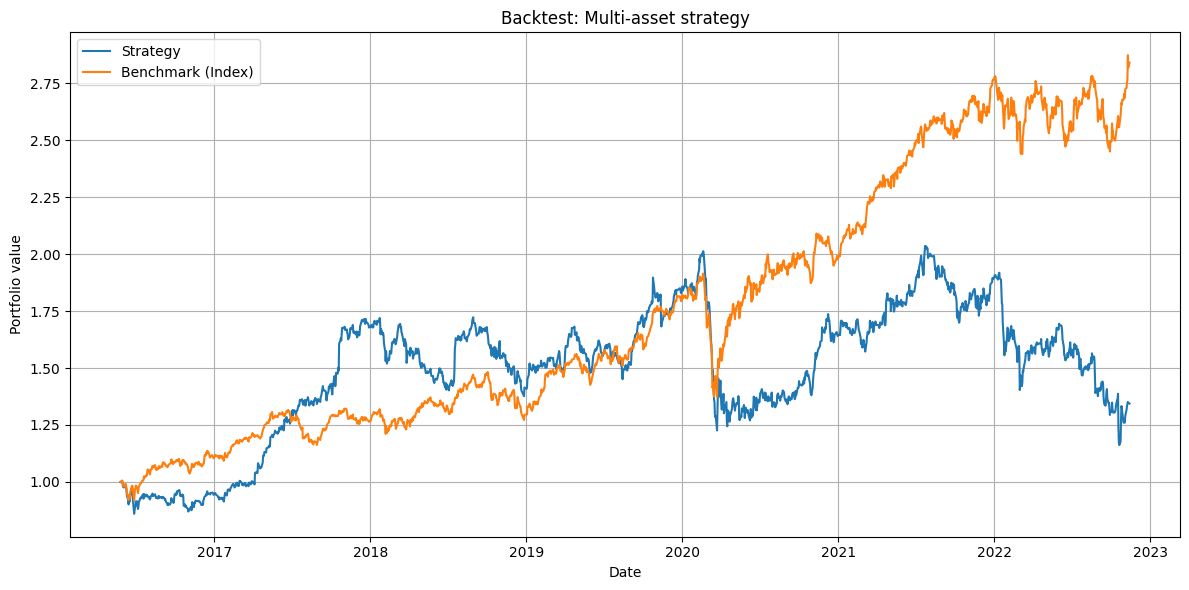

[[0.0, 0.0, 0.0, 0.4426177442073822, 0.1868903785943985, 0.18367768824100494, 2.837557395451701e-17, 3.8601594277203814e-17, 0.0, 1.8830212433759264e-17, 0.0, 0.0, 0.0, 0.18681417405605316, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [3.1755480259522983e-17, 0.0, 0.0, 6.296168612253115e-17, 9.472554075857563e-17, 2.5988577537383757e-16, 0.0, 0.0, 2.8593734569271745e-17, 3.908057155654142e-17, 0.4238430857658386, 0.5721821188926697, 3.9186599567458467e-17, 0.003974788822233677, 0.0, 3.817812826159403e-18, 7.742305316122422e-17, 6.553828093873993e-17, 0.0, 0.0, 1.2536697747783464e-16, 6.6621254748015795e-18], [1.563413709372585e-16, 1.362702370377982e-16, 0.0, 1.8286843114201346e-16, 0.0, 2.572299829770605e-16, 0.0, 0.0, 8.782746490917544e-18, 0.10750190168619156, 0.0, 0.0, 0.0, 0.4773685336112976, 0.0, 1.0044208671025609e-16, 0.41512957215309143, 1.670436454607064e-16, 0.0, 1.408961056471581e-17, 1.3244393278906065e-17, 5.61331381123385e-17], [9.708071255969376e-18, 1.142075533170532e-17, 

In [ ]:
import portfolio_optimizers.portfolio_optimizer 
importlib.reload(portfolio_optimizers.portfolio_optimizer)
from portfolio_optimizers.portfolio_optimizer import PortfolioWeightOptimizer
import importlib
import functions.backtest_multi_asset
importlib.reload(functions.backtest_multi_asset)

from functions.backtest_multi_asset import backtest_multi_asset
df_prices = df_val.copy()

df_index_raw = pd.read_csv("data/MCAP_22_Index_raw.csv", index_col="Date", parse_dates=True)
df_index = df_index_raw.copy()
df_index.columns = ["Close"]
print(df_index.head())

weight_optimizer = PortfolioWeightOptimizer(
    strategy="sharpe_opt",
    multi_horizon=True,
    risk_aversion=1.
)

result = backtest_multi_asset(
    ds_val,
    cross_attention_lstm_reg,
    weight_optimizer,
    df_prices,
    index_df=df_index,
    plot=True,
    trading_cost=0.001,
)
print(result["weights"])
print(f"Mean weights: {np.array(result['weights']).mean(axis=0)}")

               Close
Date                
2000-01-03  1.000000
2000-01-04  0.980766
2000-01-05  0.980568
2000-01-06  0.980568
2000-01-07  0.950247
Scaled returns: [0.94199016 0.93446667 0.91998365 0.9218654  0.92342807 0.91561398
 0.91165498 0.91256152 0.91853504 0.90409317]
Weights: [6.1800318e-17 0.0000000e+00 2.0729086e-18 0.0000000e+00 0.0000000e+00
 6.5206319e-01 0.0000000e+00 6.8539160e-17 3.7215736e-17 0.0000000e+00
 4.0094672e-17 4.6954494e-17 7.8849354e-18 1.2270115e-01 4.3038300e-17
 5.7520241e-18 7.9584933e-18 2.2523567e-01 1.2261581e-17 1.2886930e-19
 3.4833059e-18 0.0000000e+00]
Full horizon predictions: tensor([ 226.7586,  125.2043,  111.4553, 1552.5104,  139.0211,   60.3093,
         239.2805,  118.0790,  142.2882,  195.9395,  159.5449,  116.2640,
         112.3141,  166.9811,  196.3088,  127.9696,  102.6096,   86.0291,
         183.4505,  145.0688,   91.9520,  202.8451])
Last know prices: tensor([ 224.6278,  124.5393,  111.7046, 1514.2098,  135.1000,   57.4056,
        

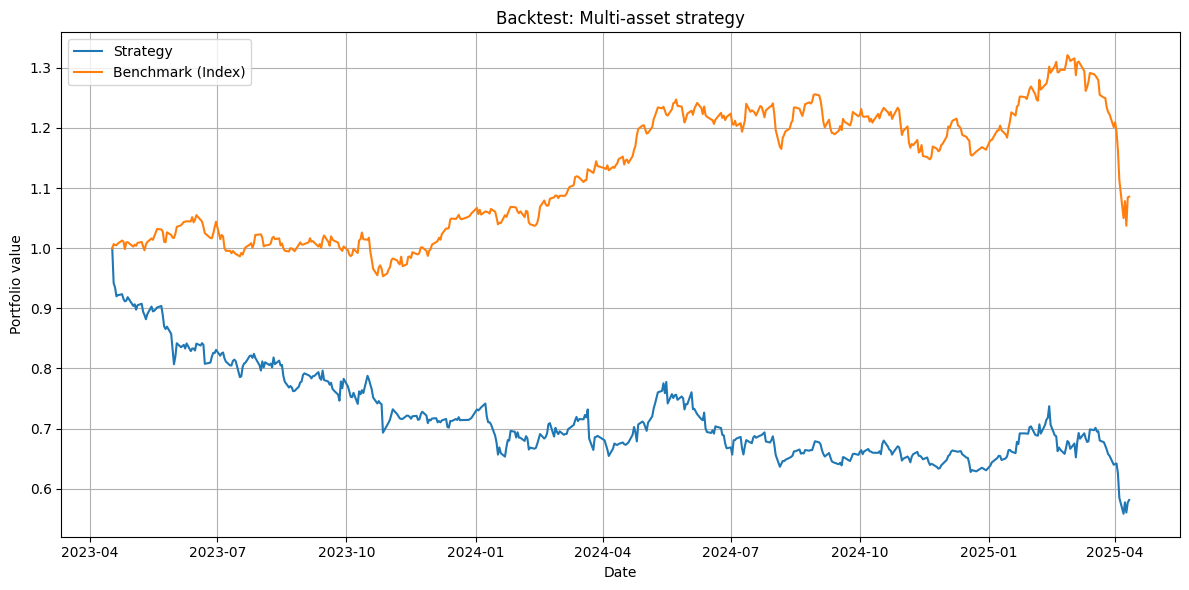

[[6.18003179250618e-17, 0.0, 2.0729086179984463e-18, 0.0, 0.0, 0.6520631909370422, 0.0, 6.853915985218431e-17, 3.721573587893247e-17, 0.0, 4.009467182647428e-17, 4.695449388126634e-17, 7.884935407400451e-18, 0.12270115315914154, 4.3038299915362636e-17, 5.7520241417431735e-18, 7.958493270552341e-18, 0.22523567080497742, 1.2261581115643022e-17, 1.2886929813829476e-19, 3.483305949526634e-18, 0.0], [0.0, 1.7677774478183036e-17, 4.419661085328799e-17, 0.0, 4.3078864852602236e-17, 0.5234139561653137, 6.6726223967748774e-18, 6.366877996247618e-17, 8.442069674095742e-18, 1.0099796697114275e-17, 2.7620196548241494e-19, 0.0, 2.5828327506441614e-17, 0.1015121191740036, 1.2490133600433262e-17, 0.0, 3.947139619799925e-18, 0.31431642174720764, 1.0137367240536434e-17, 0.0, 0.06075750291347504, 0.0], [1.3178780485537746e-16, 0.0, 0.0, 0.0, 0.7952591180801392, 6.938893903907228e-17, 5.344796095148111e-17, 0.0, 0.0, 0.0, 0.0, 4.738581298417558e-16, 0.0, 0.20474088191986084, 0.0, 0.0, 0.0, 0.0, 4.6504170

In [18]:
import portfolio_optimizers.portfolio_optimizer 
importlib.reload(portfolio_optimizers.portfolio_optimizer)
from portfolio_optimizers.portfolio_optimizer import PortfolioWeightOptimizer
import importlib
import functions.backtest_multi_asset
importlib.reload(functions.backtest_multi_asset)

from functions.backtest_multi_asset import backtest_multi_asset
df_prices = df_test.copy()

df_index_raw = pd.read_csv("data/MCAP_22_Index_raw.csv", index_col="Date", parse_dates=True)
df_index = df_index_raw.copy()
df_index.columns = ["Close"]
print(df_index.head())

weight_optimizer = PortfolioWeightOptimizer(
    strategy="sharpe_opt",
    multi_horizon=True,
    risk_aversion=1.
)

result_crossattn_lstm = backtest_multi_asset(
    ds_test,
    cross_attention_lstm_reg,
    weight_optimizer,
    df_prices,
    index_df=df_index,
    plot=True,
    trading_cost=0.001,
)
print(result_crossattn_lstm["weights"])
print(f"Mean weights: {np.array(result_crossattn_lstm['weights']).mean(axis=0)}")

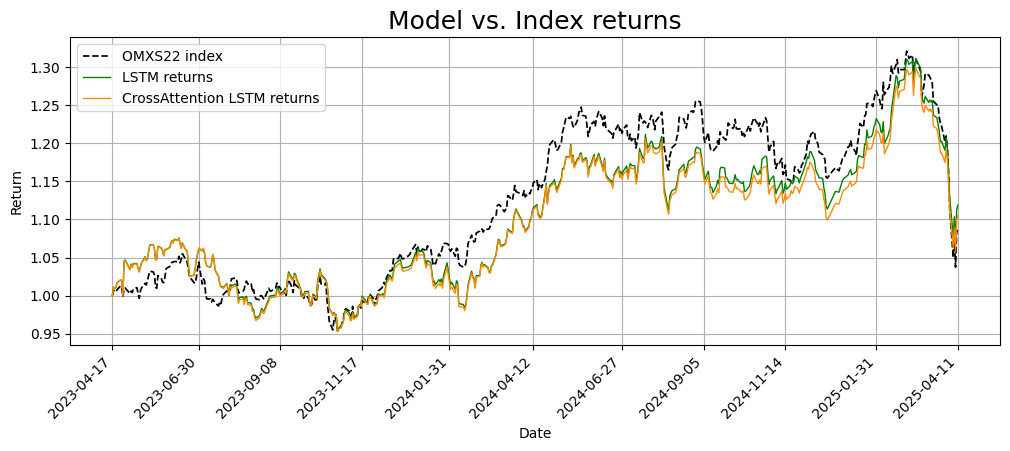

LSTM portfolio value: 1.1187
CrossAttention LSTM portfolio value: 1.1048
Index value: 1.0856
LSTM Sharpe Ratio: 1.1848
CrossAttention LSTM Sharpe Ratio: 1.1645
Index Sharpe Ratio: 1.2037
LSTM Max Drawdown: -0.1825
CrossAttention LSTM Max Drawdown: -0.1846
Index Max Drawdown: -0.2146


In [16]:
portfolio_dates = result_crossattn_lstm["dates"]
crossattn_lstm_portfolio_vals = result_crossattn_lstm["values"]
index_vals = result_crossattn_lstm["benchmark"]
lstm_portfolio_vals = result_lstm["values"]


plt.figure(figsize=(12, 4))
if index_vals is not None:
    plt.plot(portfolio_dates[:], np.array(index_vals[:])/index_vals[0], label="OMXS22 index", color="black", linewidth=1.25, linestyle="--")
plt.plot(portfolio_dates[:], np.array(lstm_portfolio_vals[:])/lstm_portfolio_vals[0], label="LSTM returns", color="green", linewidth=1.0)
plt.plot(portfolio_dates[:], np.array(crossattn_lstm_portfolio_vals[:])/crossattn_lstm_portfolio_vals[0], label="CrossAttention LSTM returns", color="darkorange", linewidth=1.0)
plt.xlabel("Date")
plt.xticks(
        portfolio_dates[::50], 
        #[d.strftime('%Y-%m-%d') for d in dates],
        rotation=45, ha='right'
    )
plt.ylabel("Return")
plt.title("Model vs. Index returns", fontsize=18)
plt.grid()
plt.legend()
plt.show()
print(f"LSTM portfolio value: {(np.array(lstm_portfolio_vals[:])/lstm_portfolio_vals[0])[-1]:.4f}")
print(f"CrossAttention LSTM portfolio value: {(np.array(crossattn_lstm_portfolio_vals[:])/crossattn_lstm_portfolio_vals[0])[-1]:.4f}")
print(f"Index value: {(np.array(index_vals[:])/index_vals[0])[-1]:.4f}")

def sharpe_ratio(returns, risk_free_rate=0.0):
    """
    Calculate the Sharpe ratio of a series of returns.
    """
    excess_returns = returns - risk_free_rate
    return np.mean(excess_returns) / np.std(excess_returns)

def max_drawdown(returns):
    """
    Calculate the maximum drawdown of a series of returns.
    """
    peak = np.maximum.accumulate(returns)
    drawdown = (returns - peak) / (1 + peak)
    return np.min(drawdown)

# Calculate the performance metrics
lstm_returns = np.array(lstm_portfolio_vals[:])/lstm_portfolio_vals[0] - 1
crossattn_lstm_returns = np.array(crossattn_lstm_portfolio_vals[:])/crossattn_lstm_portfolio_vals[0] - 1
index_returns = np.array(index_vals[:])/index_vals[0] - 1
lstm_sharpe = sharpe_ratio(lstm_returns)
crossattn_lstm_sharpe = sharpe_ratio(crossattn_lstm_returns)
index_sharpe = sharpe_ratio(index_returns)
lstm_max_drawdown = max_drawdown(lstm_returns)
crossattn_lstm_max_drawdown = max_drawdown(crossattn_lstm_returns)
index_max_drawdown = max_drawdown(index_returns)
print(f"LSTM Sharpe Ratio: {lstm_sharpe:.4f}")
print(f"CrossAttention LSTM Sharpe Ratio: {crossattn_lstm_sharpe:.4f}")
print(f"Index Sharpe Ratio: {index_sharpe:.4f}")
print(f"LSTM Max Drawdown: {lstm_max_drawdown:.4f}")
print(f"CrossAttention LSTM Max Drawdown: {crossattn_lstm_max_drawdown:.4f}")
print(f"Index Max Drawdown: {index_max_drawdown:.4f}")
    

In [1]:
def plot_allocations(alloc, tickers, dates):
    n_assets, T = alloc.shape
    # Stack allocations
    cumsum = np.cumsum(alloc, axis=0)
    base_cmap = plt.get_cmap('tab20c')
    extra_cmap = plt.get_cmap('tab20b')
    colors = []
    for i in range(n_assets):
        if i < 10:
            colors.append(base_cmap(i))  # tab20 has 20 distinct
        else:
            # pick from hsv evenly for any extras
            colors.append(extra_cmap((i-10) / max(1, n_assets-10)))

    #cmap = plt.get_cmap('tab20', n_assets)
    #colors = [cmap(i) for i in range(n_assets)]

    plt.figure(figsize=(9,4))
    for i, ticker in enumerate(tickers):
        bottom = cumsum[i-1] if i>0 else np.zeros(T)
        top    = cumsum[i]
        # use dates on the x-axis
        plt.fill_between(dates, bottom, top, step='post', label=ticker, color=colors[i])

    # now the ticks are the dates themselves
    plt.xticks(
        dates[::45], 
        #[d.strftime('%Y-%m-%d') for d in dates],
        rotation=45, ha='right'
    )

    plt.xlabel('Date')
    plt.ylabel('Allocation')
    plt.title('Asset Allocations Over Time')
    plt.legend(ncol=2, bbox_to_anchor=(1.02,1), loc='upper left')
    plt.tight_layout()
    plt.show()

weights = np.array(result_lstm["weights"])  # shape: (num_rebalances, num_assets)
dates = np.array(result_lstm["dates"])      # dagliga datum (len = N)

allocations_filled = np.zeros((len(tickers), len(dates)))

rebalance_idxs = np.linspace(0, len(dates)-1, len(weights), dtype=int)
for i in range(len(rebalance_idxs)):
    start = rebalance_idxs[i]
    end = rebalance_idxs[i+1] if i+1 < len(rebalance_idxs) else len(dates)
    allocations_filled[:, start:end] = np.expand_dims(weights[i], axis=1)

plot_allocations(allocations_filled[:, :], tickers, dates[:])
print(allocations_filled.shape)

NameError: name 'np' is not defined